## **Exploring US markets correlation**

In this notebook we will explore the covariance between the daily returns of the major US indices and determine their relationship. In simple terms, we will investigate how closely *related* are the different US indices and what deviations between them could signal.

Daily data from S&P 500, NASDAQ Composite and Dow Jones Industrial Average over 35 years will be used (1990-2025), alongside the Treasury Bill discount rates in the same period. We will download our data from Yahoo Finance.

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
start = '1990-01-01'
end = '2026-01-01'
interval = '1d'

ticker_nq = yf.Ticker('^IXIC') #ticker for NASDAQ Composite
ticker_es = yf.Ticker('^SPX') #ticker for S&P 500
ticker_dw = yf.Ticker('^DJI') #ticker for Dow Jones Industrial Average
ticker_tb = yf.Ticker('^IRX') #ticker for Treasury Bills discount rates

df_nq = ticker_nq.history(start=start, end=end, interval=interval)
df_es = ticker_es.history(start=start, end=end, interval=interval)
df_dw = ticker_dw.history(start=start, end=end, interval=interval)
df_tb = ticker_tb.history(start=start, end=end, interval=interval)

df_es

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,0.0,0.0
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,0.0,0.0
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,0.0,0.0
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000,0.0,0.0
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000,0.0,0.0
...,...,...,...,...,...,...,...
2025-12-24 00:00:00-05:00,6904.910156,6937.319824,6904.910156,6932.049805,1798270000,0.0,0.0
2025-12-26 00:00:00-05:00,6936.020020,6945.770020,6921.600098,6929.939941,2586550000,0.0,0.0
2025-12-29 00:00:00-05:00,6903.600098,6920.209961,6888.759766,6905.740234,3541750000,0.0,0.0


We will work with daily returns; $$Return_{t} = \frac{Close_t - Close_{t-1}}{Close_{t-1}} $$
which can be easily calculated by the *pct_change* function. 

In [3]:
nq = df_nq['Close'].pct_change().dropna()
sp = df_es['Close'].pct_change().dropna()
dw = df_dw['Close'].pct_change().dropna()

sp

Date
1990-01-03 00:00:00-05:00   -0.002586
1990-01-04 00:00:00-05:00   -0.008613
1990-01-05 00:00:00-05:00   -0.009756
1990-01-08 00:00:00-05:00    0.004514
1990-01-09 00:00:00-05:00   -0.011787
                               ...   
2025-12-24 00:00:00-05:00    0.003221
2025-12-26 00:00:00-05:00   -0.000304
2025-12-29 00:00:00-05:00   -0.003492
2025-12-30 00:00:00-05:00   -0.001376
2025-12-31 00:00:00-05:00   -0.007358
Name: Close, Length: 9066, dtype: float64

Now let's calculate the covariance, which is given by:
$$ \operatorname{Cov}(X,Y)=\mathbb{E}[(X-\mathbb{E}[X])(Y-\mathbb{E}[Y])]=\mathbb{E}[XY]-\mathbb{E}[X]\mathbb{E}[Y] $$
Thankfully, pandas already has a pre-built method for that which we will use. After calculating the covariance we need to normalize it by dividing by the product of the individual standard deviations $σ$.
$$ ρ_{X,Y} = \frac{\operatorname{Cov}(X,Y)}{σ(X)σ(Y)} $$
Now, using a custom function that implements this formula, we can calculate the ratios of the three indices. 

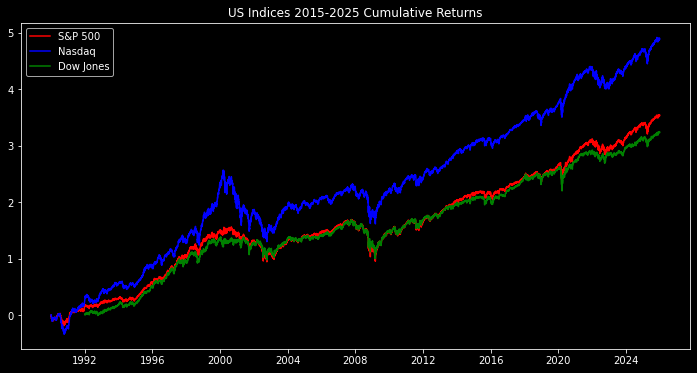

SP-NQ  ρ= 0.8918432644252234
SP-DW  ρ= 0.9667489273654585


In [4]:
def get_r(x, y): 
    cov = x.cov(y)
    std_x = x.std()
    std_y = y.std()
    return cov/(std_x*std_y)

# Draw the cumulative daily return charts (logarithmic return approximation)
plt.style.use('dark_background')
plt.figure(figsize=(12,6))

plt.title("US Indices 2015-2025 Cumulative Returns")
plt.plot(sp.cumsum(), color='red', label='S&P 500')
plt.plot(nq.cumsum(), color='blue', label='Nasdaq')
plt.plot(dw.cumsum(), color='green', label='Dow Jones')
plt.legend()
plt.show()

# Calculate and print ratios
print("SP-NQ  ρ=", get_r(sp, nq))
print("SP-DW  ρ=", get_r(sp, dw))

As we can see we have a very high $\rho_{SP,NQ} \approx 0.89$ and $\rho_{SP,DW} \approx 0.97$. Of course, this result is very much expected since the technology and industrial sectors broadly reflect the overall economic growth and investment flows that the S&P 500 represents. While the broader market grows at a relatively steady pace, speculation renders the technology sector more volatile. Simultaneously, the industrial sector grows at a slower pace, especially in the recent years, reflecting fears of an industrial falloff. 

Knowing these results, what would you expect is the ratio between the NASDAQ and Dow Jones indices? Probably something between the two ratios we found, right?

In [5]:
get_r(nq, dw)

0.8095114970914804

Surprisingly, we get a much lower $\rho_{NQ,DW} \approx 0.81$ which indicates that, while the two sectors remain extremely correlated, they are not always affected the same way by financial events in the past years. After all, they are two different sectors that, more often than not, deviate from each other.  

However, these numbers are a simple generalization over the last three decades, and are not very insightful of the different market conditions during that time. A more interesting approach would be to monitor the yearly ratios between these markets.

 We will calculate the yearly ratios and plot them alongside the yearly cumulative returns of the S&P 500.

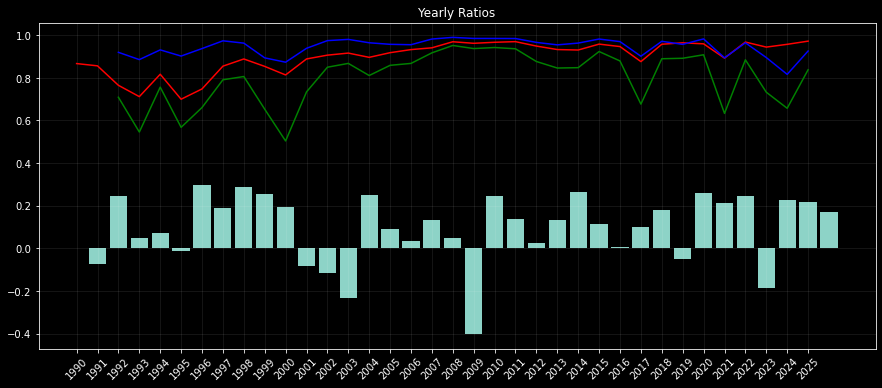

In [6]:
yyr = pd.DataFrame(index = sp.index.year.unique())

# Calculate yearly ratios
yyr['r_sp_nq'] = [
    get_r(sp[sp.index.year == y], nq[nq.index.year == y]) # for SP-NQ
    for y in yyr.index
]

yyr['r_sp_dw'] = [
    get_r(sp[sp.index.year == y], dw[dw.index.year == y]) # for SP-DW
    for y in yyr.index
]
yyr['r_nq_dw'] = [
    get_r(nq[nq.index.year == y], dw[dw.index.year == y]) # for NQ-DW
    for y in yyr.index
]

yyr.index = pd.to_datetime(yyr.index, format='%Y') # back to datetime index for efficient ploting
yyr.index = yyr.index.tz_localize(None)

# Charts
# Plot Yearly ratios
plt.figure(figsize=(15,6))
plt.title('Yearly Ratios')
plt.grid(alpha = 0.1)
plt.plot(yyr['r_sp_nq'], color='red', label='SP-NQ')
plt.plot(yyr['r_sp_dw'], color='blue', label='SP-DW')
plt.plot(yyr['r_nq_dw'], color='green', label='NQ-DW')
plt.xticks(yyr.index, rotation=45)

# Plot S&P 500 yearly returns for reference
yearly = sp.resample('YE').sum()

plt.bar(x=yearly.index, height=yearly.values, width=300)

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.show()

By carefully examining the ratios over time, we can notice that the ratios involving S&P 500 are generally steady over time, as the sectors always have great importance in the direction of the general market. However, we can observe that the ratio of Nasdaq and the Dow Jones tends to dramatically drop just before technology crashes, like the ***2000 dot com bubble crash***, hinting great speculation in the technology sector that is not affirmed by the industrial conditions.

Not all market downturns are signaled by this observation though. We do not notice the same deviation before the ***2008 crash***, likely due to high growth and speculation across all markets, and little suspicion on the impending crash. 

Getting to recent times, something similar is starting to appear; Nasdaq and Dow Jones tend to be less and less correlated, possibly signaling extreme technology speculation backed by a steady industrial advancement. Recent ***bear markets (2018, 2022)*** also followed lower correlation between the two indices. 

Another very interesting, and perhaps concerning observation, is that the correlation between the broader market and tech sector is the highest in the last decades. It is safe to assume that technology is becoming the leading indicator of growth and has achieved huge market capitalization in the recent years. 

But what does the Federal Reserve have to say in these patterns? Let's plot the fund rates alongside the correlation NQ-DW for clarity.

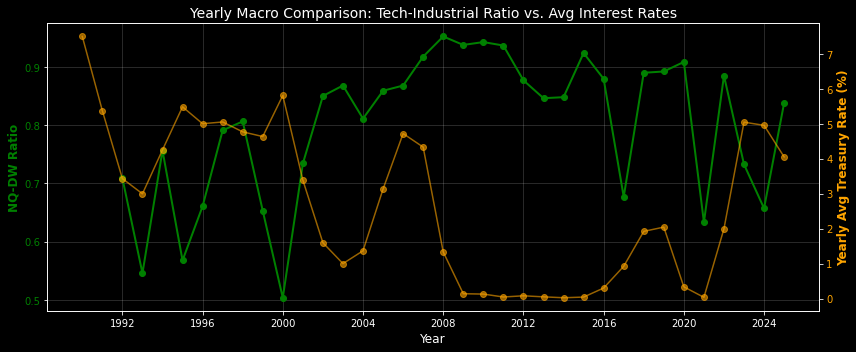

Ratio between Tech-Industrial ratio and Avg Interest Rates:  ρ= 0.3450108251202352


In [10]:
# Calculate yearly average interest rates
df_tb_yearly = df_tb['Close'].resample('YS').mean()
df_tb_yearly.index = df_tb_yearly.index.tz_localize(None)


fig, ax1 = plt.subplots(figsize=(12, 5))

# 1. Plot the Yearly NQ-DW Ratio (Green)
color_ratio = 'green'

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('NQ-DW Ratio', color=color_ratio, fontsize=12, fontweight='bold')
ax1.plot(yyr.index.values, yyr['r_nq_dw'].values, 
         color=color_ratio, marker='o', linewidth=2, label='NQ-DW Ratio')
ax1.tick_params(axis='y', labelcolor=color_ratio)
ax1.grid(alpha=0.2)

# 2. Plot the Yearly Average Treasury Rate (Orange)
ax2 = ax1.twinx()
color_rates = 'orange'

ax2.set_ylabel('Yearly Avg Treasury Rate (%)', color=color_rates, fontsize=12, fontweight='bold')
# Using the resampled yearly data here
ax2.plot(df_tb_yearly.index.values, df_tb_yearly.values, 
         color=color_rates, marker='o', alpha=0.6, label='Avg T-Bill Rate')
ax2.tick_params(axis='y', labelcolor=color_rates)

plt.title('Yearly Macro Comparison: Tech-Industrial Ratio vs. Avg Interest Rates', fontsize=14)
fig.tight_layout()
plt.show()

# Calculate Ratio 
print("Ratio between Tech-Industrial ratio and Avg Interest Rates:  ρ=", get_r(yyr['r_nq_dw'].pct_change(), df_tb_yearly.pct_change()))

We get a low correlation of $ρ \approx 0.35$, suggesting that lower-rate environments be associated with greater divergence in the technology and industry sectors, with the first traditionally responding much more aggressively to these policies. Of course, it is important to consider that rising rates can also have the adverse impact, heavily pressuring the growing tech sector as cash flows retract and prefer the safety of the high interest rates.


### **TL;DR**

Covariance in the markets is a measure generally used to determine the relations between two assets, with high positive values representing a common path to the same direction, while negative values display opposite reactions. 

In the case of the major US Indices, we notice, as expected, that they are generally moving in the same way, since there is a great variety of interconnected stocks that broadly shape the sentiment of the broad market. However, it can be meaningful to note that the technology and industrial sectors do not always develop with the same pace, sometimes signaling potential overvaluations on the volatile cutting edge tech stocks, driven by speculation. 

In this macro economic scheme, the role of the Fed is also considerable, as the Treasury Bill rates significantly redirect cash flows and cause different parts of the economy to be stimulated, that can be seen in the volatility of the correlation between the markets.  

Recent economic events, though, combined with cautious Fed policies, are starting to strengthen the gap between the rapidly growing tech and the steady growth of the broader market. A period of high volatility and uncertainty has emerged, prompting the Fed to issue careful decisions and not send the market to irrational levels. 

As most cash flows are now targeted mostly to a single sector, the question remains; is technology (and particularly AI) really the future of the economy, or is it just another bubble ready to burst?